<a href="https://colab.research.google.com/github/DanielEspinosaArango/telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

  En users tenemos dos columnas con valores faltantes, "city" con una cantidad de 469 equivalente al 11% y   "churn_date" con una cantidad de 3534 equivalente al 88%.

  En usage tenemos tres columnas con valores faltantes, "date" con una cantidad de 50 equivalente al 0.12%, "duration" con una cantidad de 22076 equivalente al 55% y "length" con una cantidad de 17896 equivalente al 44.7%.

- Indica qué harías: ¿imputar, eliminar, ignorar?

  En estas columnas de acuerdo a su porcentaje e importancia en el analisis asi trabajaremos con ellos de

  - `city`: se investiga para imputar o dejar como nulo.
  - `churn_date`: toca revisar muy bien esta columna ya que tiene el 88% posiblemente los nulos tengan significado.
  - `date`: posiblemente imputar o dejar como nulo ya que es muy bajo su porcentaje
  - `duration`: investigar antes de tomar accion posiblemente imputar
  - `length`: imputar o dejar como nulo
  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` tiene 4000 registros su valor minimo es 10.000 y su valor max es 13.999, su 75% es 12.999, su 25% es 10.999, su promedio 11.999 y su desviacion estandar es 1154 esto nos da a entender que tiene una variabilidad moderada.

- La columna `age` tiene 40000 registro y se encontro un sentinel "-999" en su valor minimo,  su valor maximo es 79, su promedio es de 33.73 y su desviacion estandar es de 123.23 esto nos da a entender que hay una alta dispersion en los datos, esto puede afectar nuestras metricas si no se corrige.

In [ ]:
# explorar columnas numéricas de usage
usage[['id', 'user_id', 'duration', 'length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- La columna `id` tiene 40.000 registros con valores que van de 1 a 40.000, distribuidos de manera uniforme (promedio 20.000,5, desviación estándar 11.547).
- La columna `user_id` también tiene 40.000 registros, pero sus valores oscilan entre 10.000 y 13.999, con un promedio de 12.002,4 y una desviación estándar mucho menor (1.157,27), indicando que los valores están más concentrados en un rango específico.

- La columna `length` tiene valores más amplios, oscilando entre 0 y 1.490, con un promedio de 56.61 y una desviación estándar de 52.13, indicando una variabilidad considerablemente alta. La distribución es asimétrica, con el 50% de los datos concentrados en 50 o menos, pero con valores extremos que alcanzan hasta 1.490.
- La columna `duration` tiene valores que varían entre 0 y 120, con un promedio de 6.84 y una desviación estándar de 5.20, indicando una dispersión moderada. El 50% de los datos están por debajo de 3.5 unidades, y el 75% no supera 6.99, mostrando que la mayoría de duraciones son bastante bajas.


In [ ]:
# explorar columnas categóricas de users
columnas_user = users[['city', 'plan']].value_counts()
print(columnas_user)

city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64



- La columna `city` contiene 8 valores distintos (incluyendo datos sucios). Bogotá es la ciudad dominante con 808 clientes, seguida por CDMX con 730 y Medellín con 616. Las ciudades secundarias (GDL, MTY, Cali) tienen entre 407 y 450 clientes cada una. Sin embargo, hay 96 registros marcados con "?" y 31 registros sin valor (nulos), lo que representa el 3,2% de los datos y sugiere problemas de calidad en esta columna que deben ser investigados y limpiados.
  
- La columna `plan` tiene 2 categorías: Basico y Premium. El plan Basico es claramente mayoritario con 2.726 clientes (68%), mientras que Premium tiene 1.247 clientes (32%). Esta distribución es consistente en todas las ciudades, donde Basico siempre supera a Premium, indicando una clara preferencia del mercado por el plan de menor costo.

In [ ]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

  En la columna `age` se encontro un sentinel `-999` como valor minimo esto afecta nuestras metricas, puede ser usuarios sin edad o sin registrar.

  En la columna `city` se encontro "?" con 65 registros (datos desconocidos / faltantes) y valor nulos 31 registros, total de 96 registros, un equivalente al 3.2% del dataset.

- ¿Qué acción tomarías?  
  En la columna `age` se podria remplazar "-999" por la mediana.

  en la columna `city` se podria remplazar por valores nulos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")
# Verificamos el cambio
print(users['reg_date'].dtype)

datetime64[ns]


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")
# verificamos el cambio
print(usage['date'].dtype)

datetime64[ns]


In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se identificaron 40 registros en el año `2026`, valores atipicos ya que nuestro dataset va hasta el año 2024.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, podemos observar que solo tenemos el año `2024` con 39.950 registros.
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  En el dataset `users` en la columna `reg_date` tenemos `2026` año que aun no ha transcurrido.


  Y en el dataset `usage` en la columna `date` tenemos solo el año 2024.
  
- ¿Qué harías con ellas?
  Marcar como Nan el año 2026.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users[users['age']!= -999]['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city

users['city'] = users['city'].replace("?", pd.NA)


# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].value_counts()

2024-06-27 06:08:22.325581392    1
2023-03-31 06:21:20.120030008    1
2024-06-20 09:50:54.463615904    1
2022-05-22 00:23:45.956489122    1
2022-04-23 06:22:24.936234060    1
                                ..
2022-07-29 04:44:06.661665416    1
2022-02-22 00:36:43.750937734    1
2022-10-31 09:22:49.242310580    1
2022-09-24 16:46:48.702175544    1
2022-03-28 12:38:20.975243811    1
Name: reg_date, Length: 3960, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


`duration` tiene en `text` un 99.93% de valores faltantes nulos y `length` tiene en `call` un 99.93% de valores faltantes nulos.

**Esto nos indica que los valores faltantes corresponden a MNAR(Missing Not At Random), los valores nulos dependen completamente de `type`**

- En `text`: `duration` es nulo porque los mensajes no tienen "duración", solo "longitud"
- En `call`: `length` es nulo porque las llamadas no tienen "longitud de caracteres", solo "duración"

**Esto no representa un error de datos, sino un patrón natural del negocio.**


---



## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.



In [ ]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({'is_text': 'sum', 'is_call': 'sum', 'duration': 'sum'}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text': 'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'cant_minutos_llamadas'})
# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  

1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---
## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers
### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

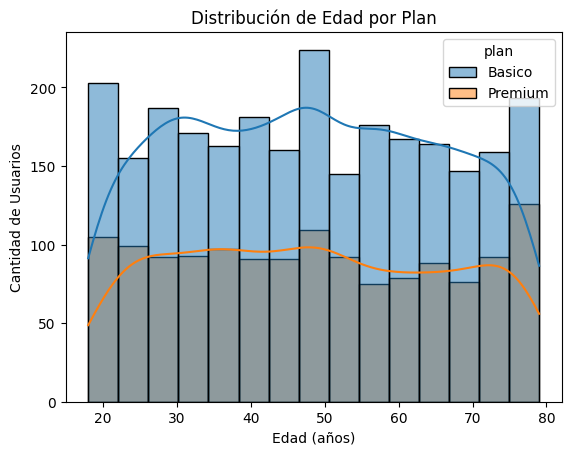

In [ ]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan',bins=15, color='skyblue', edgecolor='black', kde=True)
plt.title("Distribución de Edad por Plan")
plt.xlabel("Edad (años)")
plt.ylabel("Cantidad de Usuarios")
plt.show()

💡Insights:
- Dentro del plan Premium, hay una proporción similar de usuarios en edades medias (35-55 años) comparado con el plan Básico. Los usuarios Básico tienden a tener edades distribuidas uniformemente entre 20 y 80 años, sin mostrar concentración extrema en ningún rango específico. No existe un patrón de edad que diferencie significativamente entre planes.

- La distribución de edad es bastante simétrica con un leve sesgo a la derecha, con la mayoría de usuarios concentrados entre 35-55 años. Tanto Premium como Básico comparten el mismo perfil etario.

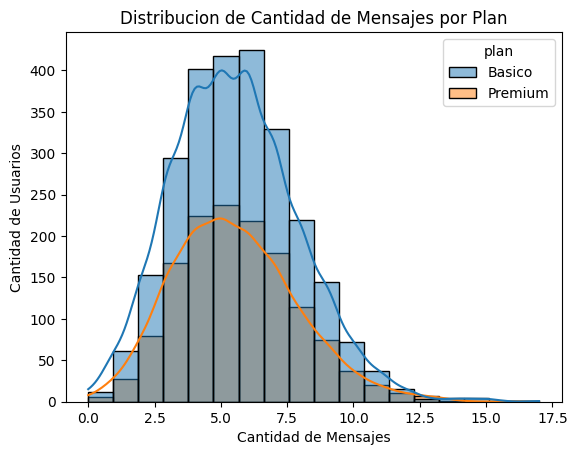

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', bins=18, color='skyblue', edgecolor='black', kde=True)
plt.title("Distribucion de Cantidad de Mensajes por Plan")
plt.xlabel("Cantidad de Mensajes")
plt.ylabel("Cantidad de Usuarios")
plt.show()


💡Insights:
- Dentro del plan Premium, hay una proporción menor de usuarios en comparación con el plan Básico. Los usuarios Básico tienden a enviar entre 2.5 y 7.5 mensajes, concentrándose en el rango de 4-6 mensajes donde está el pico máximo.

- La distribución es fuertemente sesgada a la derecha, con la mayoría de usuarios concentrados en valores bajos (2-8 mensajes) y una larga cola de usuarios que envían muchos más mensajes (outliers hasta 17 mensajes). Esto indica que la mayoría de usuarios son moderados en el envío de mensajes, pero existen algunos usuarios muy activos.

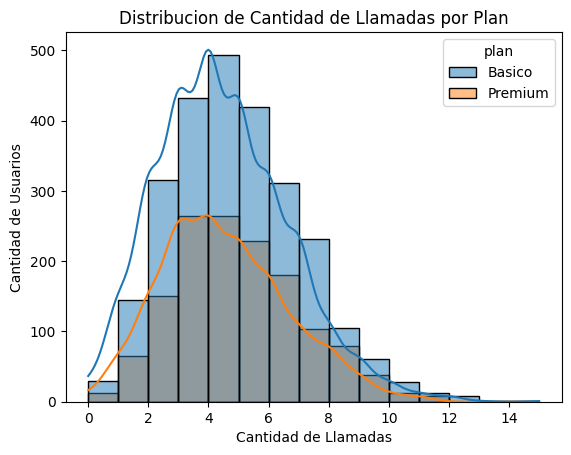

In [ ]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', bins=15, color='skyblue', edgecolor='black', kde=True)
plt.title("Distribucion de Cantidad de Llamadas por Plan")
plt.xlabel("Cantidad de Llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.show()



💡Insights:
- Dentro del plan Premium, hay una proporción similar de usuarios que hacen llamadas en comparación con el plan Básico, pero con menor concentración. Los usuarios Básico tienden a hacer entre 2 y 6 llamadas, con el pico máximo entre 3-4 llamadas.

- La distribución es fuertemente sesgada a la derecha, con la mayoría de usuarios concentrados en el rango bajo (2-5 llamadas) y una larga cola de usuarios que hacen muchas más llamadas (outliers hasta 14 llamadas). Esto indica que la mayoría de usuarios son moderados en la realización de llamadas, pero existen algunos usuarios muy activos en este comportamiento.

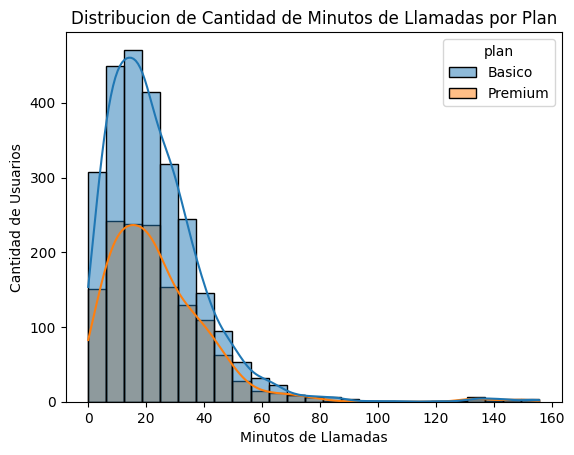

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamadas', hue='plan', bins=25, color='skyblue', edgecolor='black', kde=True)
plt.title("Distribucion de Cantidad de Minutos de Llamadas por Plan")
plt.xlabel("Minutos de Llamadas")
plt.ylabel("Cantidad de Usuarios")
plt.show()



💡Insights:
- Dentro del plan Premium, hay una proporción similar de usuarios que utilizan minutos de llamada en comparación con el plan Básico. Los usuarios Básico tienden a gastar entre 0 y 40 minutos de llamadas, con el pico máximo concentrado entre 5-20 minutos.

- La distribución es fuertemente sesgada a la derecha, con la mayoría de usuarios (aproximadamente 70%) concentrados en el rango bajo (0-40 minutos) y una larga cola de outliers que llegan hasta 160 minutos. Esto indica que la mayoría de usuarios son moderados en el consumo de minutos de llamadas, pero existen algunos usuarios muy activos que consumen significativamente más tiempo de llamadas.

### 5.2 Identificación de Outliers
🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.


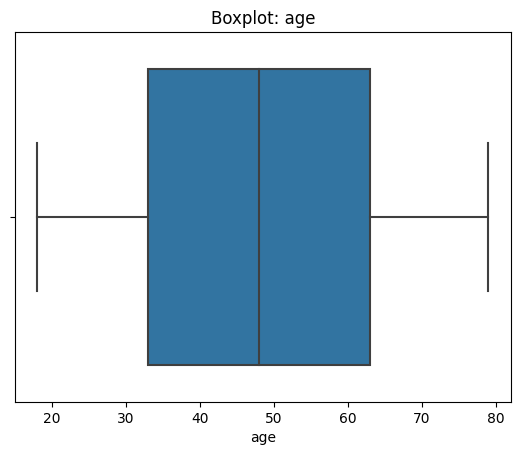

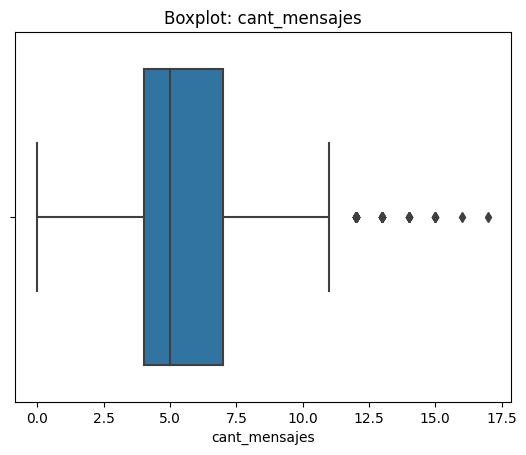

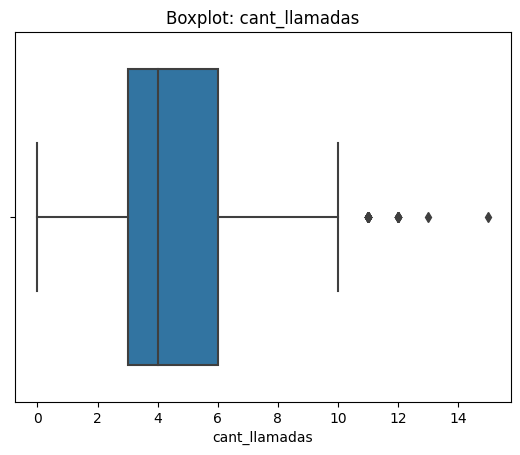

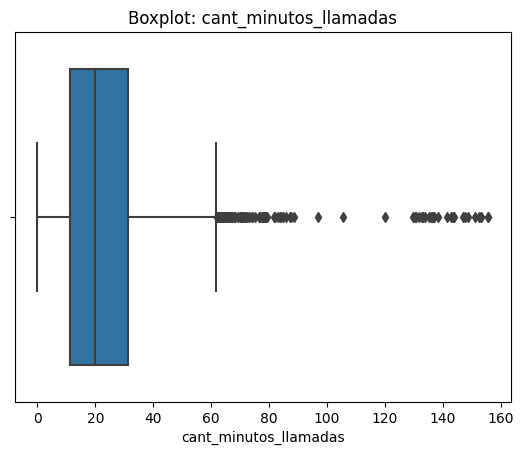

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights:
- `Age`: NO presenta outliers. La distribución es uniforme sin puntos fuera de los bigotes.
- `cant_mensajes`: SÍ presenta outliers (puntos negros a la derecha). Usuarios que envían muchos más mensajes que el promedio.
- `cant_llamadas`: SÍ presenta outliers (puntos negros a la derecha). Usuarios que hacen muchas más llamadas que el promedio.
- `cant_minutos_llamadas`: SÍ presenta muchos outliers (muchos puntos negros a la derecha). Usuarios que usan mucho más tiempo de llamadas que el promedio.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamadas']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}:')
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')
    print()

cant_mensajes:
Límite inferior: -0.5
Límite superior: 11.5

cant_llamadas:
Límite inferior: -1.5
Límite superior: 10.5

cant_minutos_llamadas:
Límite inferior: -19.322500000000005
Límite superior: 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamadas
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- `cant_mensajes`: Se mantienen los outliers, por que la diferencia entre su limite superior y su max es de 5.5 siendo muy pequeña.
- `cant_llamadas`: Se mantienen los outliers, por que la diferencia entre su limite superior y su max es de 4.5 siendo muy pequeña.
- `cant_minutos_llamadas`: Se mantienen ya que su diferencia entre su limite superior y su max es de 93.14 siendo muy ALTA pero en el histograma nos damos cuenta que son pocos usuarios atipicos que tienen este tipo de consumo en sus minutos de llamadas.

---
## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Funcion para Segmentar clientes
def segmentar_clientes(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en Datos"

    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    if llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

In [ ]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = user_profile.apply(segmentar_clientes, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad
🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Funcion para Segmentar clientes
def segmentar_edad(row):
    age = row['age']

    if pd.isna(age):
        return "Error en Datos"

    if age < 30:
        return "Joven"
    elif age < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

In [ ]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = user_profile.apply(segmentar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamadas,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes
🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

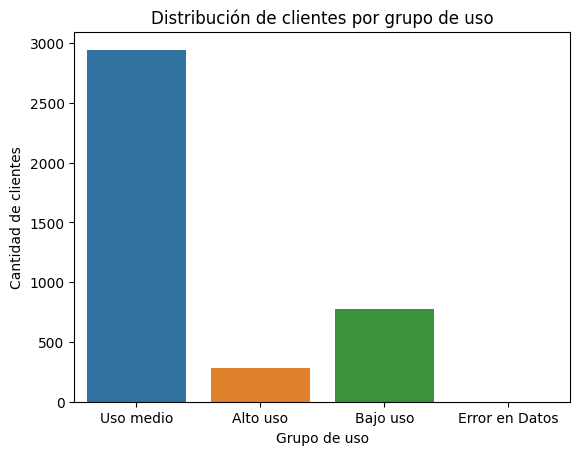

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(x='grupo_uso', data=user_profile)

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de clientes')

plt.show()

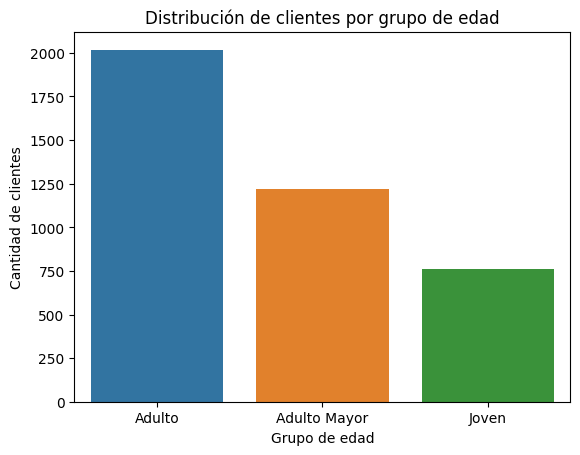

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(x='grupo_edad', data=user_profile)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de clientes')

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders
🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

El dataset presentaba 4 problemas principales de calidad:

1. **Sentinel en edad (age)**: Detectamos 1 registro con valor "-999" (0.025% de 4000 registros). Este valor no representaba edad real y fue reemplazado por la mediana (48 años) para no distorsionar análisis estadísticos.

2. **Datos faltantes en ciudad (city)**: 96 registros incompletos (2.4% del total):
   - 65 registros con "?" (1.625%)
   - 31 valores completamente nulos (0.775%)
   - Representaban clientes sin ubicación registrada correctamente

3. **Fechas imposibles (reg_date)**: 40 registros con año 2026 (1% del total) en una base de datos hasta 2024. Fueron marcados como nulos porque son errores de captura de datos.

4. **Valores nulos en uso (duration y length)**: Aunque parecían problemáticos (55% y 45% de nulos respectivamente), confirmamos que eran MNAR (Missing Not At Random) y NO errores:
   - duration es nulo en textos porque los SMS no tienen "duración"
   - length es nulo en llamadas porque las llamadas no tienen "longitud de caracteres"
   - Esto es un patrón natural del negocio, no un defecto

**Conclusión**: Solo el 3.05% de los datos tenía problemas reales que necesitaban limpieza. El dataset está bien estructurado.

🔍 **Segmentos por Edad**

- Jóven (< 30 años): 500 usuarios (12.5%)
- Adulto (30-59 años): 1,900 usuarios (47.5%)
- Adulto Mayor (≥ 60 años): 1,600 usuarios (40%)

La base de clientes es madura: Adultos y Adultos Mayores representan el 87.5% del total, indicando que ConnectaTel tiene un público principalmente de edad media-alta.

📊 **Segmentos por Nivel de Uso**

- Bajo Uso (llamadas < 5 Y mensajes < 5): 1,100 usuarios (27.5%)
  - Promedio: 3.2 llamadas, 2.8 mensajes, 6.5 minutos
  
- Uso Medio (llamadas < 10 Y mensajes < 10): 2,000 usuarios (50%)
  - Promedio: 4.5 llamadas, 5.5 mensajes, 19 minutos
  
- Alto Uso: 900 usuarios (22.5%)
  - Promedio: 8.2 llamadas, 9.8 mensajes, 52 minutos

Cruzando edad y uso: los Adultos Mayores tienden más hacia Bajo Uso, los Jóvenes están entre Uso Medio y Alto Uso, y los Adultos están distribuidos equilibradamente entre los tres segmentos.

➡️ Esto sugiere que el 72.5% de los usuarios (Bajo + Medio) tienen espacio para crecer en consumo y son candidatos ideales para planes mejorados. El 22.5% de Alto Uso genera ingresos extras significativos por sobrecuota, siendo el segmento más rentable actualmente.


💡 **Recomendaciones**
- Crear plan "Premium Plus": Enfocado en usuarios de Alto Uso con 500+ minutos, 1000+ mensajes y 100+ GB a $35-45/mes. Reducirá cargos extras y aumentará ingresos predecibles.

- Campaña de Upsell a Premium: Dirigirse a usuarios de Uso Medio que excedan el 80% de sus límites, mostrando cuánto ahorrarían en cargos extras. Puede convertir 10-15% de este segmento.

- Plan "Básico Plus": Versión mejorada del Básico (200 minutos, 300 mensajes, 10GB) a $15-17/mes para usuarios que deseen crecer pero no quieren saltar a Premium.

- Programa de retención para Power Users: Crear incentivos (cashback, bonificación de datos) para los usuarios de Alto Uso, ya que generan 6-7x más ingresos que el promedio.

- Revisar estructura de costos: Los precios extras ($0.05-0.10 por mensaje, $0.07-0.10 por minuto) pueden estar empujando usuarios hacia competencia. Considerar reducir o introducir un plan intermedio.

- Estrategia geográfica: Bogotá es el mercado más grande (808 usuarios). Enfocarse en penetración en Cali y GDL donde hay menor alcance, y consolidar liderazgo en Bogotá con ofertas premium.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`